# Artificial Neural Network (ANN)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from keras import models
from keras import layers
from keras import optimizers
import warnings
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
warnings.filterwarnings("ignore")

In [3]:
df = pd.read_csv('data/cleaned_data.csv')

In [4]:
X = df.drop(columns=['target'])
y = df['target']
print('Columns:', X.columns.tolist())

Columns: ['Age', 'G', 'GS', 'MP', 'FG', 'FGA', 'FG%', 'ORB', 'DRB', 'TRB', 'AST', 'STL', 'BLK', 'TOV', 'PF', 'PTS', '3P', '3PA', '3P%', '2P', '2PA', '2P%', 'eFG%', 'career_ft_pct', 'prev_ft_pct', 'career_seasons', 'height_in', 'weight_lb', 'ast_to_tov', 'pts_per_fga', 'threep_rate', 'reb_per_min', 'stocks_per_min', 'scoring_load', 'Pos_C', 'Pos_PF', 'Pos_PG', 'Pos_SF', 'Pos_SG']


In [5]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print('Train:', X_train.shape, '  Test:', X_test.shape)

Train: (12016, 39)   Test: (3004, 39)


In [6]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

In [7]:
network = models.Sequential()
network.add(layers.Input(shape=(39,)))
network.add(layers.Dense(64, activation='relu'))
network.add(layers.Dense(32, activation='relu'))
network.add(layers.Dense(24, activation='relu'))
network.add(layers.Dense(16, activation='relu'))
network.add(layers.Dense(1))

In [9]:
network.compile(optimizer=optimizers.RMSprop(learning_rate=0.01),loss='mse',metrics=['mae'])

network.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         2,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 24)             │           792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 16)             │           400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,849 (22.85 KB)

 Trainable params: 5,849 (22.85 KB)

 Non-trainable params: 0 (0.00 B)

In [12]:
ann = network.fit(X_train_scaled, y_train,
                    validation_data=(X_test_scaled, y_test),
                    epochs=18,
                    batch_size=20)

Epoch 1/18
601/601 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.1738 - mae: 0.3498 - val_loss: 0.1584 - val_mae: 0.3029
Epoch 2/18
601/601 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.1541 - mae: 0.3149 - val_loss: 0.1598 - val_mae: 0.3088
Epoch 3/18
601/601 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.1510 - mae: 0.3068 - val_loss: 0.1555 - val_mae: 0.3229
Epoch 4/18
601/601 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.1495 - mae: 0.3038 - val_loss: 0.1569 - val_mae: 0.3209
Epoch 5/18
601/601 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.1507 - mae: 0.3065 - val_loss: 0.1505 - val_mae: 0.3032
Epoch 6/18
601/601 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.1471 - mae: 0.2993 - val_loss: 0.1574 - val_mae: 0.3006
Epoch 7/18
601/601 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.1464 - mae: 0.2976 - val_loss: 0.1601 - val_mae: 0.3452
Epoch 8/18
601/601 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.1463 - mae: 0.2986 - val_loss: 0.1498 - val_mae: 0.3023
Epoch 9/18
601/601 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - lo

In [13]:
predictions_vector = network.predict(X_test_scaled)
y_pred = (predictions_vector > 0.5).astype(int).flatten()
acc = accuracy_score(y_test, y_pred)
print(f"Accuracy: {acc*100:.2f}%")

94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Accuracy: 76.90%


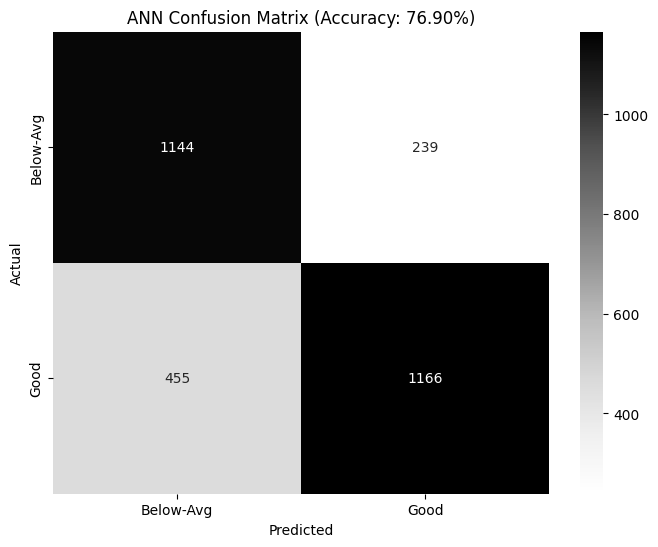

In [16]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greys',
            xticklabels=['Below-Avg', 'Good'],
            yticklabels=['Below-Avg', 'Good'])
plt.title(f'ANN Confusion Matrix (Accuracy: {acc*100:.2f}%)')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.savefig('ann_confusion_matrix.png', bbox_inches='tight')
plt.show()

In [18]:
joblib.dump(ann, 'ann.pkl')
joblib.dump(scaler, 'ann_scaler.pkl')

['ann_scaler.pkl']